In [28]:
!pip install cpmpy[choco,gurobi,exact] numpy networkx colorama tqdm hyperopt pandas --quiet
import cpmpy as cp
import numpy as np
import pandas as pd

(You can ignore google* and tensor* dependency errors on Google Colab.)

# **Session 6: Low-level encodings | CP search strategies and algorithm configuration**

This sixt and final excercise session will be split into two parts.

First we'll finish the last two remaining steps in CPMpy's transformation waterfall; looking at the lower-level technologies of Pseudo-Boolean and SAT.

Next we'll look at the "solve" part in "model+solve" and play around with the different backends, their options, and how to effectively use these degrees of freedom to improve solving performance.


**Useful Resources:**
* CPMpy summary sheet: https://cpmpy.readthedocs.io/en/latest/summary.html
* CPMpy modeling documentation: https://cpmpy.readthedocs.io/en/latest/modeling.html

* List of supported solvers / solving technologies: https://cpmpy.readthedocs.io/en/latest/#supported-solvers
* Documentation on hyperparameter configuration: https://cpmpy.readthedocs.io/en/latest/modeling.html#hyperparameter-search-across-different-parameters

## PART 1: Low-level modelling

### **Exercise 1: PB encodings**

In this exercise we'll encode some simple constraints directly in Pseudo Boolean (PB).

As seen in the lectures, PB only accepts Pseudo-Boolean Constraints:
$\sum_{i=1}^{n}a_i*x_i \le b$

where $a_i$ , $b$ are integer constants and $x_i$ are Boolean decision variables. It extends SAT by allowing linear inequalities over Boolean variables.


We'll try out two encoding styles for representing integers using only constants and boolean decision variables: `direct` and `order`

- **Direct**: Create a Boolean variable $b_{[x=k]}$ for all $k \in \{0..n\}$

- **Order**: Create a Boolean variable $b_{[x≥k]}$ for all $k \in \{0..n+1\}$

For example for the range $k \in \{0...3\}$ we would get:

**Direct encoding:**

| k | b[k=0] | b[k=1] | b[k=2] | b[k=3] |
| - | - | - | - | - |
| 0 | 1 | 0 | 0 | 0 |
| 1 | 0 | 1 | 0 | 0 |
| 2 | 0 | 0 | 1 | 0 |
| 3 | 0 | 0 | 0 | 1 |

**Order encoding:**

| k | b[k>=0] | b[k>=1] | b[k>=2] | b[k>=3] | b[k>=4] |
| - | - | - | - | - | - |
| 0 | 1 | 0 | 0 | 0 | 0 |
| 1 | 1 | 1 | 0 | 0 | 0 |
| 2 | 1 | 1 | 1 | 0 | 0 |
| 3 | 1 | 1 | 1 | 1 | 0 |

As you can see, the first and last column of the order encoding (b[k>=0] and b[k>=4]) are allways respectively 1 and 0. So from an information-theory point of view they don't contribute anything and are thus often not shown:

| k | b[k>=1] | b[k>=2] | b[k>=3] |
| - | - | - | - |
| 0 | 0 | 0 | 0 |
| 1 | 1 | 0 | 0 |
| 2 | 1 | 1 | 0 |
| 3 | 1 | 1 | 1 |

In [29]:
"""
Some support code for the exercise.
No need to look at this.
"""
def create_table(n, consistency, x_equals_k, x_lessthen_k, x_greaterthen_k):
  table = []
  for i in range(n+1):
    a = []
    for encoding, b in zip(["direct", "order"],[b_direct, b_order]): # collect encodings
      m = cp.Model(); m.add(consistency(b, encoding)); m.add(x_equals_k(i, b, encoding)); sat = m.solve()
      if not sat: raise Exception("Model is UNSAT")
      a.extend([int(a.value()) if a.value() is not None else -1 for a in b])
    for encoding, b in zip(["direct", "order"],[b_direct, b_order]): # collect x < 3
      m = cp.Model(); m.add(x_lessthen_k(3, b, encoding)); m.add(consistency(b, encoding)); m.add(x_equals_k(i, b, encoding))
      a.append(m.solve())
    for encoding, b in zip(["direct", "order"],[b_direct, b_order]): # collect x > 3
      m = cp.Model(); m.add(x_greaterthen_k(3, b, encoding)); m.add(consistency(b, encoding)); m.add(x_equals_k(i, b, encoding))
      a.append(m.solve())
    table.append(a)

  # Create MultiIndex for columns
  columns = pd.MultiIndex.from_tuples(
      [('direct', f"b[x={i}]") for i in range(len(b_direct))] +
      [('order', f"b[x>={i}]") for i in range(len(b_order))] +
      [('x < 3', 'direct'), ('x < 3', 'order')] +
      [('x > 3', 'direct'), ('x > 3', 'order')]
  )
  df = pd.DataFrame(table, columns=columns)

  # Function to apply style
  def highlight_col(col):
      # Apply a left border to the first column of the 'order' encoding
      if col.name == ('order', 'b[x>=0]'): return ['border-left: 3px solid black' for _ in col]
      if col.name == ('x < 3', 'direct'):  return ['border-left: 3px solid black' for _ in col]
      if col.name == ('x > 3', 'direct'):  return ['border-left: 3px solid black' for _ in col]
      return ['' for _ in col]

  def color_correctness(col):
      name = col.name  # MultiIndex: (expr_name, encoding)
      if name[0] == "x < 3": return ["background-color: lightgreen" if col.iloc[i] == (i < 3) else "background-color: lightcoral" for i in range(len(col))]
      if name[0] == "x > 3": return ["background-color: lightgreen" if col.iloc[i] == (i > 3) else "background-color: lightcoral" for i in range(len(col))]
      return [""] * len(col)

  # Apply the style to the DataFrame
  display(df.style.apply(highlight_col, axis=0).apply(color_correctness, axis=0))

Now start filling in the missing code:

In [30]:
# Parameters of the Problem
n = 5 # range of integer values (0..n) for which we will create the boolean encodings

# Decision Variables
b_direct = cp.boolvar(shape=(n+1), name=[f"b[x={i}]" for i in range(n+1)])  # booleans for the direct encoding
b_order = cp.boolvar(shape=(n+2), name=[f"b[x>={i}]" for i in range(n+2)])  # booleans for the order encoding
# HINT: print these variables to get a better idea on what you are dealing with.


def consistency(b, encoding):
  """
  TODO: Implement the consistency constraints for the two encoding styles
        as seen in the lectures (you should really revisit the slides to know
        which constraints to implement). These constraints must make sure that
        the allowed values for the set of boolean variables represent something
        meaningfull in the chosen encoding.

        For example:
        - [0, 1, 0] is a valid direct encoding for the number 1,
        - [0, 1, 1] is not one-hot and does not represent any number at all
                    in our direct encoding scheme

  HINT: To go over a list in pairs, you can use "zip":
          for (a,b) in zip(x[:-1], x[1:]) # iterate over two copies of the same list, but one shifted by one element

            x = [ x0, x1, x2, x3]
            x[:-1] = [ x0, x1, x2]
            x[1:]  = [ x1, x2, x3]
            zip(x[:-1], x[1:]) = [(x0, x1), (x1, x2), (x2, x3)] # zip goes over the two lists together,
                                                                # returning each time a tuple with the next element from each

        or using "itertools":
          import itertools
          for (a,b) in itertools.pairwise(x)
  """
  if encoding == "direct":
    # return True # <- return the constraint that models the consistency for the
              # direct encoding (see lecture slides)
    # ┌────SOLUTION────┐
    return cp.sum(b) == 1
    # └────────────────┘
  elif encoding == "order":
    # return [] # <- replace (will be more than one constraint)
    return [
        #1) order consistency constraint
        # ┌────SOLUTION────┐
        cp.all([b2.implies(b1) for (b1,b2) in zip(b[:-1], b[1:])]),
        # └────────────────┘

        #2) bounds consistency constraint
        # ┌────SOLUTION────┐
        (b[0] & ~b[-1])
        # └────────────────┘
    ]

def x_equals_k(k, b, encoding):
  """
  TODO: Implement x == k for the two encoding styles.
        Your constraints must enforce the expression on the set of boolean
        decision variables used to encode the integer value.
  """
  if encoding == "direct":
    # Direct encoding of x == k
    # return True # <- replace
    # ┌────SOLUTION────┐
    return b[k]
    # └────────────────┘
  elif encoding == "order":
    # Order encoding of x == k
    # return True # <- replace
    # ┌────SOLUTION────┐
    return b[k] & ~b[k+1] # x == k <-> x >= k and x < k+1 <-> x >= k and ~(x > =k+1)
    # └────────────────┘

def x_lessthen_k(k, b, encoding):
  """
  TODO: Implement x < k for the two encoding styles.
  """
  if encoding == "direct":
    # Direct encoding of x < k
    # return True # <- replace
    # ┌────SOLUTION────┐
    return cp.any(b[:k]) # x == 0 or x == 1 or ... x == k-1
    # └────────────────┘
  elif encoding == "order":
    # Order encoding of x < k
    # return True # <- replace
    # ┌────SOLUTION────┐
    return ~b[k] # # x < k <-> ~(x >= k) <-> ~b[k]
    # └────────────────┘

# --- BONUS ---
def x_greaterthen_k(k, b, encoding):
  """
  TODO: Implement x > k for the two encoding styles.
  HINT: Be carefull, it's a strict inequality.
  """
  if encoding == "direct":
    # Direct encoding of x > k
    # return True # <- replace
    # ┌────SOLUTION────┐
    return cp.any(b[k+1:])
    # └────────────────┘
  elif encoding == "order":
    # Order encoding of x > k
    # return True # <- replace
    # ┌────SOLUTION────┐
    return b[k+1] # x > k <-> x >= k+1 <-> b[k+1]
    # └────────────────┘

# Visualise and check your implementation
create_table(n, consistency, x_equals_k, x_lessthen_k, x_greaterthen_k)

### **Exercise 2: PB Graph Coloring**

In the previous exercise sessions, when posting a CP-model to a specific solver / solving technology we've always relied on CPMpy to do the transformations for us. In this exercise, we'll try directly modeling a complete problem in the lower-level language of a solver technology. More specificaly, creating a pseudo-boolean model.



#### 0. Setup

In [31]:
"""
Load helper functions for the graph coloring problem.
No need to look at this code.
"""
import networkx as nx
import matplotlib.pyplot as plt
from cpmpy.expressions.utils import flatlist
from typing import List
import re

draw = lambda g, **kwargs: (nx.draw_circular(g, width=5, node_size=1500, **kwargs), plt.show())
cmap = plt.get_cmap('tab10').colors #["black", "yellow", "cyan", "lightgreen", "blue"]

def get_colors(color:List[int]):
    return [cmap[c] for c in color]

def show_graph(nodes, edges, colors=[], conflicts=[], satisfiable=[], corrections=[], **kwargs):
    """
    Visualizes a graph for the graph coloring problem.
    """
    # Create networkX graph
    G = nx.Graph()
    G.add_nodes_from(list(range(len(nodes))))
    G.add_edges_from([(a, b) for (a,b) in edges])
    nx_pos = nx.circular_layout(G)
    conflicts = flatlist(conflicts)
    satisfiable = flatlist(satisfiable)
    corrections = flatlist(corrections)
    conflict_edges = []
    for c in conflicts:
        n1, n2 = c.args
        if n1.name == "max": continue
        a = int(re.search(r"\[[0-9]*\]", str(n1)).group()[1:-1]); b = int(re.search(r"\[[0-9]*\]", str(n2)).group()[1:-1])
        conflict_edges.append((a, b))
    sat_edges = []
    for c in satisfiable:
        n1, n2 = c.args
        if n1.name == "max": continue
        a = int(re.search(r"\[[0-9]*\]", str(n1)).group()[1:-1]); b = int(re.search(r"\[[0-9]*\]", str(n2)).group()[1:-1])
        sat_edges.append((a, b))
    correction_edges = []
    for c in corrections:
        n1, n2 = c.args
        if n1.name == "max": continue
        a = int(re.search(r"\[[0-9]*\]", str(n1)).group()[1:-1]); b = int(re.search(r"\[[0-9]*\]", str(n2)).group()[1:-1])
        correction_edges.append((a, b))
    # Create figure
    fig, ax = plt.subplots()
    nx.draw(G, nx_pos, with_labels=False, node_size=2000, node_color="white", font_size=20, font_color="black", ax=ax)
    nx.draw_networkx_labels(G, nx_pos)
    edge_colors = ["red" if (a, b) in conflict_edges else ("green" if (a,b) in sat_edges else ("orange" if (a,b) in correction_edges else "black")) for (a, b) in G.edges()]
    if len(colors) != 0: kwargs |= {"node_color": get_colors(colors)}
    # Draw edges
    nx.draw_networkx_edges(G, nx_pos, edgelist=G.edges(), edge_color=edge_colors, width=2, ax=ax)
    # Draw nodes
    draw(G, edge_color=edge_colors, **kwargs)
    plt.tight_layout()
    plt.show()

In [32]:
"""
Load helper functions to check for a valid Pseudo-Boolean model.
No need to look at this code.
"""
from cpmpy.expressions.utils import argvals
from cpmpy.transformations.flatten_model import flatlist
from cpmpy.expressions.variables import _BoolVarImpl, NegBoolView
from cpmpy import SolverLookup

def check_pb_variables(model):
    """
    Checks if all variables of a model are boolean variables.
    """
    solver = SolverLookup().get("ortools", model)
    invalid_counter = 0
    for var in solver.user_vars:
        if not isinstance(var, _BoolVarImpl):
            print(f"{invalid_counter} | Invalid PB model: {var} is not a boolean variable!")
            invalid_counter += 1
    return invalid_counter == 0

def check_pb_constraints(model):
    """
    Checks if all constraints of a model are valid pseudo-boolean constraints.
    """
    invalid_counter = 0
    for constraint in flatlist(model.constraints):
        if constraint.name == "==":
          print(f"{invalid_counter} | Invalid PB model: {constraint} is not a valid PB constraint, equalities must be split up into two inequalities.")
        elif constraint.name == ">=" or constraint.name == "<=":
            if constraint.args[0].name == "sum":
                if all([isinstance(a, _BoolVarImpl) for a in constraint.args[0].args]):
                    pass
                else:
                    print(f"{invalid_counter} | Invalid PB model: {constraint} is not a valid PB constraint")
                    invalid_counter += 1
            else:
                print(f"{invalid_counter} | Invalid PB model: {constraint} is not a valid PB constraint")
                invalid_counter += 1
            if type(constraint.args[1]) == int:
                pass
            else:
                print(f"{invalid_counter} | Invalid PB model: {constraint} is not a valid PB constraint")
                invalid_counter += 1
        elif constraint.name == "or":
            if type(constraint.args[0]) == _BoolVarImpl or type(constraint.args[0]) == NegBoolView:
                pass
            else:
                print(f"{invalid_counter} | Invalid PB model: {constraint} is not a valid PB constraint")
                invalid_counter += 1
            if type(constraint.args[1]) == _BoolVarImpl or type(constraint.args[1]) == NegBoolView:
                pass
            else:
                print(f"{invalid_counter} | Invalid PB model: {constraint} is not a valid PB constraint")
                invalid_counter += 1

    return invalid_counter == 0

def check_pb_model(model):
    """
    Checks if a model is a valid pseudo-boolean model.
    """
    return check_pb_variables(model) and check_pb_constraints(model)

#### 1. PB Graph Coloring model

Examine the following problem instance and high-level model for the Graph Coloring problem:

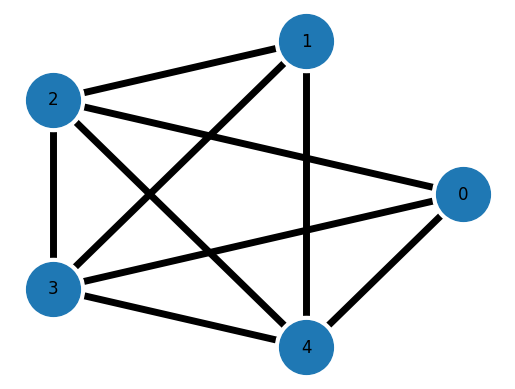

<Figure size 640x480 with 0 Axes>

In [33]:
# Problem instance
nodes = [0, 1, 2, 3, 4]
edges = [(nodes[i], nodes[j]) for i in range(len(nodes)) for j in range(i+1, len(nodes)) if (i,j) not in [(0,1)]] # fully connected, except between nodes 0 and 1

# Visualize the graph
show_graph(nodes, edges)

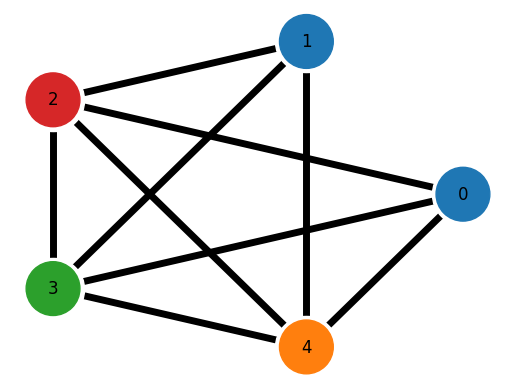

<Figure size 640x480 with 0 Axes>

In [34]:
"""
A basic model for the Graph Coloring problem.
(Just have a quick look, this was one of the exercises in a previous session)
"""

# Parameters of the Problem
n = len(nodes)  # number of nodes
c = 4           # number of colors

# Decision Variables
x = cp.intvar(0, c-1, shape=n, name='x') # for each node, one integer representing the assigned color

# Model
model = cp.Model()

# Constraints
for (i,j) in edges:
    # 1) neighbouring nodes (connected by an edge) cannot have the same color
    model.add(x[i] != x[j])

# Solve
if model.solve():
    show_graph(nodes, edges, colors=x.value())

Translate this model to a Pseudo-Boolean representation. This entails only using boolean decision variables and simple linear constraints, such as a sum, an "or", a negation, a linear inequality, ...

In [ ]:
# Parameters of the Problem
n = len(nodes)  # number of nodes
c = 4           # number of colors

# Decision Variables
"""
TODO: Choose a set of decision variables that represent the color assignments across the nodes.
      Keep in mind that pseudo-boolean solving only works with boolean decision variables.
      Make use of the "direct encoding" for representing integers using booleans.

HINT: Direct encoding = one-hot encoding of integers.
      i.e.  for each integer decision variable
            |  for each possible value of said integer variable
            |  |  create a boolean decision variable indicating whether that value is assigned to the variable

      Or in the context of colors:
            for each node
            |  for each possible color
            |  |  create a boolean decision variable indicating whether that color is assigned to the node
"""

# Decision Variables
# B = ... direct / one-hot encoding
# ┌────SOLUTION────┐
# B[i,j] = 1 iff node i has color j
B = cp.boolvar(shape=(n,c), name="B")
# └────────────────┘

# Model
model = cp.Model()

# Constraints
# 1) Consistency constraints
"""
TODO: Your chosen set of boolean decision variables are a direct encoding of originally a set
      of integer decision variables. To make sure that the encoding functions as intended,
      since not all assignments to these boolean variables represent valid integers,
      add the required "Consistency Constraints".

      For example:
       - [0, 1, 0] is a valid direct encoding for the number 1,
       - [0, 1, 1] is not one-hot and does not represent any number at all
                   in our chosen encoding scheme
"""
# ┌────SOLUTION────┐
# Exactly 1 color must be assigned to each node, no more, no less.
for i in range(n):
    # model.add(cp.sum(B[i, :]) == 1) # <- needs to be split into two inequalities
    model.add(cp.sum(B[i, :]) >= 1)
    model.add(cp.sum(B[i, :]) <= 1)
# └────────────────┘


"""
TODO: Formulate, over your chosen set of decision variables,
      that neighbouring nodes cannot get the same color.

HINT: Node A and node B both not having color "red" can
      also be formulated as:
         "either node A does NOT have color 'red',
          or node B does NOT have color 'red'"
         ~ (color(A) = "red") | ~ (color(B) = "red")
"""

for (i,j) in edges: # for each pair of neighbours
    for k in range(c): # for each color
        # ~ (color(i) = k) | ~ (color(j) = k)
        # ┌────SOLUTION────┐
        model.add(~B[i,k] | ~B[j,k]) # cannot both have that color at the same time
        # └────────────────┘

# Check if the model you've created stays within the language of a pseudo-boolean solver
if check_pb_model(model):
    print("Model is Pseudo-Boolean")

# Solve the model
if model.solve():
    print("B:")
    print(B.value())
else:
    print("No valid configuration found.")

Model is Pseudo-Boolean
B:
[[False False False  True]
 [False False False  True]
 [False False  True False]
 [False  True False False]
 [ True False False False]]


If everything went correctly (no warning messages were shown), you've now created a Pseudo-Boolean model. Whether it is correct, i.e. it still represents the original Graph Coloring Problem, is a different question.

Fill in the below function that can check whether a given coloring (list of integers) is a solution to the original coloring problem.

MCS:
   (x[1]) != (x[2])
[0 1 1 2 3] is NOT a valid coloring of the graph


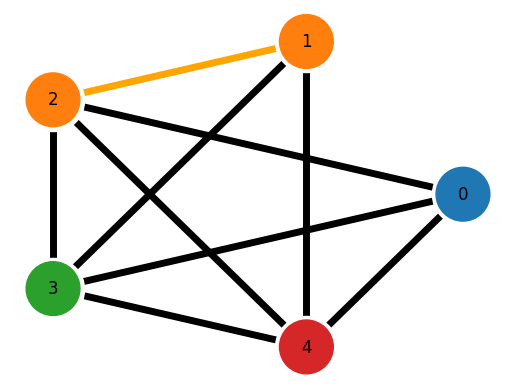

<Figure size 640x480 with 0 Axes>

[0 0 1 2 3] is a valid coloring of the graph


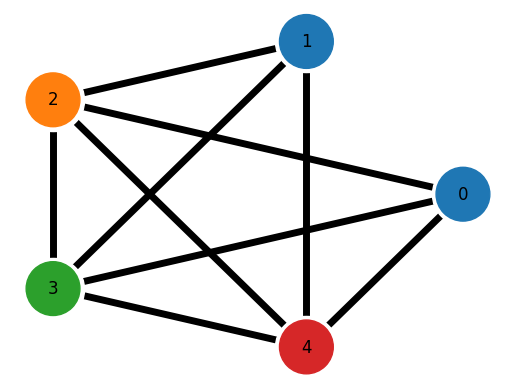

<Figure size 640x480 with 0 Axes>

In [36]:
# We'll use some tools from the advances topic lecture on eXplainable Constraint Programming.
# In this case, a Minimal Correction Subset (MCS); a minimal set of constraints we could remove from
# our CP model to turn it from being UNSAT into SAT.
# I.e. what constraints should we drop so that the problem becomes solvable?
from cpmpy.tools.explain.mcs import mcs

def check_solution(nodes, edges, colors):
    """
    Given a list of integers representing colors ('colors'),
    checks if it is a valid solution to the Graph Coloring problem of
    a graph with 'nodes' and 'edges'.

    (uses the original integer-based representation)
    """

    # Original CP-model
    x = cp.intvar(0, c-1, shape=n, name='x')
    model = cp.Model()
    for (i,j) in edges:
        model.add(x[i] != x[j])

    """
    TODO: To check if a set of values (in this case color assignments)
          is a valid solution to a model, we can enforce that solution
          through a collection of constraints and see if the model is
          still SAT.

          E.g. we have a set of values 'vals' and want to check if they
          formulate a solution to a model with as decision variables 'vars'.
          By adding 'vars == vals' to the model, solving it will either return
          SAT meaning that indeed 'vals' is a valid solution, or UNSAT meaning
          that 'vals' violates one or more constraints.
          -> we can then use MUS/MCS techniques to explain the UNSAT

          Now check the input 'colors' (argument of this function) against
          the above CP model to see if it is a valid solution.
    """
    # Enforce the 'colors' as the solution
    # model.add(...)
    # ┌────SOLUTION────┐
    model.add(x == colors)
    # └────────────────┘

    sat = model.solve()

    if sat: # Is indeed a solution
        print(f"{colors} is a valid coloring of the graph")
        show_graph(nodes, edges, colors=x.value())
    else: # Is not a solution
        # We can use an MCS to explain the unsatisfiability
        MCS = mcs(model.constraints, hard=[x == colors])
        print("MCS:")
        for constraint in MCS:
            print("  ", constraint)
        print(f"{colors} is NOT a valid coloring of the graph")
        show_graph(nodes, edges, colors=x.value(), corrections=MCS)


# An example of a invalid solution
colors = np.array([0, 1, 1, 2, 3])
check_solution(nodes, edges, colors)

# An example of a valid solution
colors = np.array([0, 0, 1, 2, 3])
check_solution(nodes, edges, colors)

The above solution checker can only check models with the same integer decision variables as seen in the original CP graph coloring model. The earlier Pseudo-Boolean model uses a Direct Encoding of integers to boolean decision variables. As seen in the lectures, we can easily convert them back.

\begin{equation}
  x = \sum_k k*b_{[x=k]}
\end{equation}

Complete the below code to go from the boolean decision variables back to integers through the direct encoding. You should now be able to check the solution coming from the pseudo-boolean model.

[3, 3, 2, 1, 0]
[3, 3, 2, 1, 0] is a valid coloring of the graph


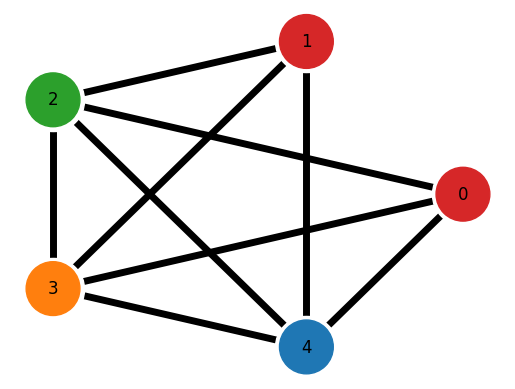

<Figure size 640x480 with 0 Axes>

In [37]:
"""
TODO: Write 'X', representing a set of integers, in terms of your
      proposed set of boolean variables based on their Direct Encoding.
      Use the above formula to calculate each x in X (one for each node).
"""

# x = [...f(i, B)... for i in range(n)] # with 'f' the above function

# ┌────SOLUTION────┐
X = [
      sum([k * B[i,k].value() for k in range(c)])
      for i in range(n)
    ]
# └────────────────┘

# Print the solution in integer representation
print(X)

# Check our solution
check_solution(nodes, edges, X)

### **Exercise 3: SAT encoding**

In this exercise we'll go to the lowest level in the waterfall; SAT. More specifically, we'll restrict our expressions to conjunctions, disjunctions and negations of boolean decision variables.

E.g.:
  $A \iff B$\
  can be written as\
  $(\neg A \vee B) \wedge (\neg B \vee A)$\
  or as\
  $(A \wedge B) \vee (\neg A \wedge \neg B)$

You can always validate this using a truth table.

> Note: You are only allowed to negate a boolean decision variable, so not
$\neg (A \wedge B)$ but instead $\neg A \vee \neg B$.

Below you'll model a task to timeslot assignment problem:
- each task must be assigned to a single timeslot
- a timeslot can be assigned to at most one task

With one additional constraint:
- if task 0 gets assigned to slot 0, then task 1 must be assigned to slot 1



In [38]:
"""
Helper functions for checking your solution.
No need to look at this code.
"""
# --- Visualization function ---
def visualize_solution_with_text(assignment):
    talks_per_slot = assignment.sum(axis=0)
    fig, ax = plt.subplots(figsize=(nr_time_slots*2, nr_tasks*1.5))
    plt.subplots_adjust(right=0.6)  # leave space for textual panel
    # Detect violations
    mistakes = []
    # 1. Slot overbooking
    for j in range(nr_time_slots):
        if talks_per_slot[j] > 1:
            mistakes.append(f"Slot {j} has {talks_per_slot[j]} talks assigned (should be ≤1).")
    # 2. Conditional dependency violation
    conditional_violated = assignment[0,0] == 1 and assignment[1,1] == 0
    if conditional_violated:
        mistakes.append("Task 0 is in slot 0 but task 1 is not in slot 1 (violates conditional dependency).")
    for i in range(nr_tasks):
        for j in range(nr_time_slots):
            assigned = assignment[i,j]
            color = "skyblue" if assigned else "white"

            # Borders: red for overbooking, orange for conditional violation
            if talks_per_slot[j] > 1: edgecolor = "red"; linewidth = 3
            elif conditional_violated and ((i,j) == (0,0) or (i,j) == (1,1)): edgecolor = "orange"; linewidth = 3
            else: edgecolor = "black"; linewidth = 1.5
            rect = plt.Rectangle((j, nr_tasks-1-i), 1, 1, facecolor=color, edgecolor=edgecolor, linewidth=linewidth)
            ax.add_patch(rect)
            if assigned: ax.text(j+0.5, nr_tasks-1-i+0.5, f"T{i}", ha="center", va="center", fontsize=12, fontweight="bold")

    # Axes
    ax.set_xlim(0, nr_time_slots)
    ax.set_ylim(0, nr_tasks)
    ax.set_xticks(np.arange(nr_time_slots)+0.5)
    ax.set_xticklabels([f"Slot {t}" for t in range(nr_time_slots)])
    ax.set_yticks(np.arange(nr_tasks)+0.5)
    ax.set_yticklabels([f"Task {t}" for t in range(nr_tasks)][::-1])
    ax.set_aspect('equal')
    ax.invert_yaxis()
    ax.set_title("Talk to Slot Assignment")
    # --- Textual panel with mistakes ---
    text_x = nr_time_slots + 0.2
    text_y = nr_tasks
    ax_text = fig.add_axes([0.65, 0.1, 0.3, 0.8])  # position [left, bottom, width, height]
    ax_text.axis('off')
    if mistakes: text_lines = ["Detected mistakes:"]; text_lines += [f"- {m}" for m in mistakes]
    else: text_lines = ["No detected mistakes. All constraints satisfied!"]
    ax_text.text(0, 1, "\n".join(text_lines), va='top', ha='left', fontsize=11)
    plt.show()

# --- Callback for solveAll ---
def callback(): assignment = x.value(); visualize_solution_with_text(assignment)

Fill in the missing code:

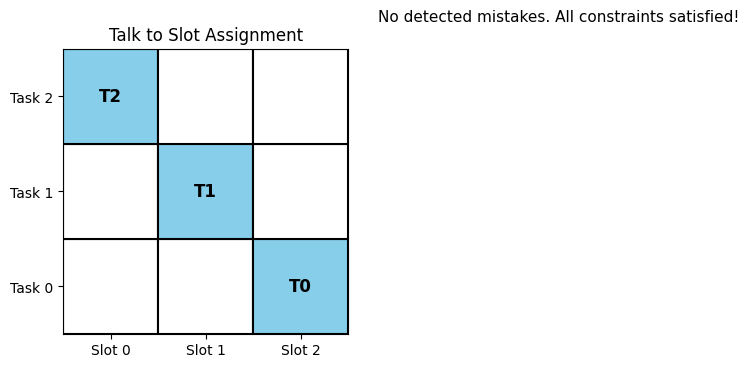

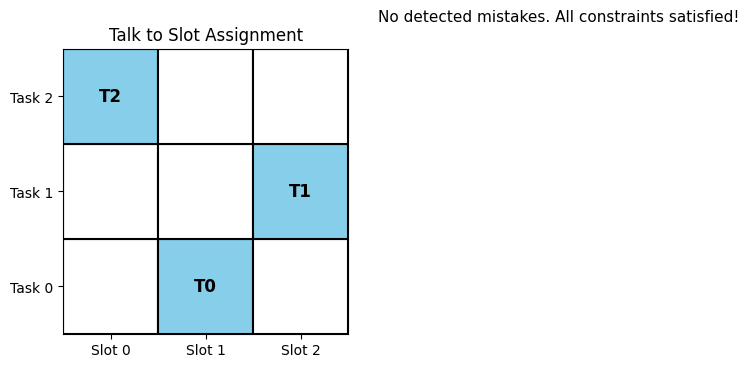

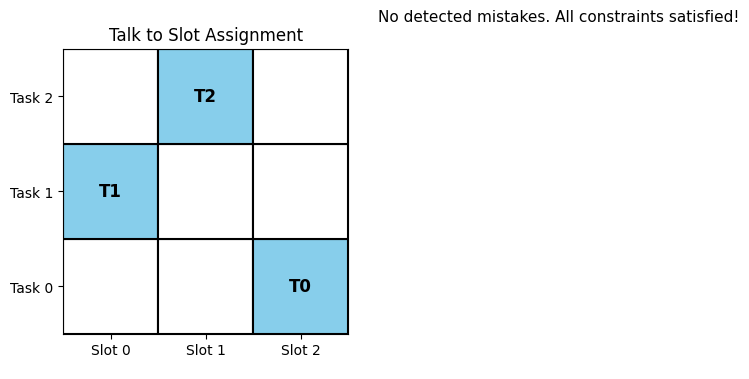

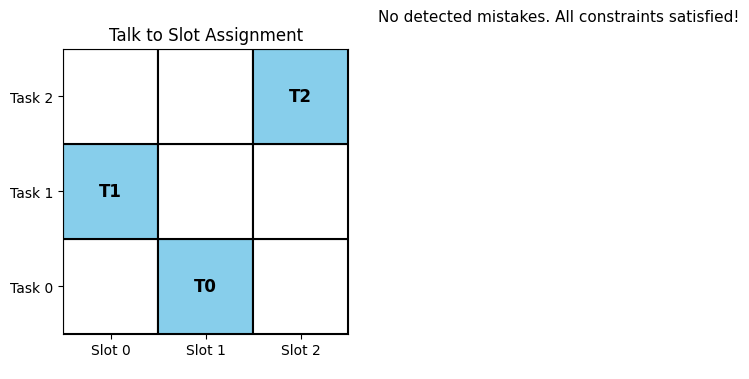

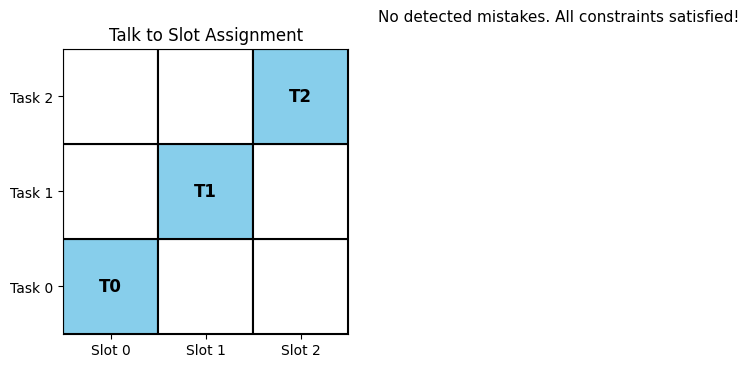

5

In [39]:
"""
TODO: Complete the below SAT model of the task to time slot assignment problem.
"""

# Parameters of the Problem
nr_tasks = 3
nr_time_slots = 3

# Decision Variables
x = cp.boolvar(shape=(nr_tasks, nr_time_slots))

# Model
model = cp.Model()

# Constraints
# 1) each task assigned to exactly one slot
for i in range(nr_tasks): # for every task
  # HINT: you are allowed to hard-code the number of timeslots
  #       (i.e. assume it will always be 3)
  # HINT: The resulting formula will be in Disjunctive Normal Form (DNF) format.
  # ┌────SOLUTION────┐
  model.add(
      (x[i][0] & ~x[i][1] & ~x[i][2]) | # task i assigned to timeslot 0
      (~x[i][0] & x[i][1] & ~x[i][2]) | # task i assigned to timeslot 1
      (~x[i][0] & ~x[i][1] & x[i][2])   # task i assigned to timeslot 2
  )
  # └────────────────┘

# 2) no two tasks assigned to the same slot
for t in range(nr_time_slots): # for every time slot
  for i in range(nr_tasks): # for every pair of tasks
    for j in range(i+1, nr_tasks):
      # model.add(...)
      # ┌────SOLUTION────┐
      model.add(~x[i,t] | ~x[j,t])
      # └────────────────┘

# 3) if task 0 assigned to slot 0, task 1 assigned to slot 1
# HINT: How would your translate an implication "A -> B" into CNF?
#       Write down a truth table to discover the matching boolean expression.
# ┌────SOLUTION────┐
# A -> B <=> ~A | B
model.add(~x[0,0] | x[1,1]) # x[0,0] -> x[1,1]
# └────────────────┘

# Check your solution
model.solveAll(display=callback)

## PART 2: Algorithm selection and configuration

In this part we'll experiment a bit with the solver backend, the second component to the "model+solve" paradigm.

### **Exercise 4: Algorithm Selection**

Depending on the (type of) problem that you're trying to solve, one solver backend / solving technology might be more suited than the other. It is always a good idea to experiment a bit as to see what works best, before settling on one particular backend (and possibly start making optimisations tailored specifically towards that one solver).

Below is a collection of models to some simple problems:

- Task allocation problem
- Team assignment problem
- Pizza voucher problem

Simply run the 3 cells and continue below...

In [40]:
def task_allocation():
    """
    See exercise session 2
    """

    # Parameters of the problem
    n_tasks = 6        # Number of tasks
    n_workers = 6      # Number of workers

    # Decision Variables
    task_assignment = None # task_assignment[j] == i iff worker i is assigned to task j
    task_assignment = cp.intvar(0, n_workers-1, shape=n_tasks, name="task_assignment") # task_assignment[j] = the worker assigned to task j

    # Model
    model = cp.Model()

    # Constraints
    model += []
    # 1) Each task is assigned to exactly one worker.
    # -> no need to model this constraint, since the chosen encoding for 'task_assignment'
    #    will already enforce this (each task j can only have one worker task_assignment[j] as value)
    # 2) Allow each worker to maximally have one task assigned = no to tasks can have the same worker
    model.add(cp.AllDifferent(task_assignment))

    # Conditional implications
    model.add((task_assignment[0] == 0).implies(task_assignment[2] != 1)) # If worker 0 is assigned to task 0, worker 1 not on task 2
    model.add((task_assignment[1] == 1).implies(task_assignment[0] == 2)) # If worker 1 is assigned to task 1, worker 2 must be assigned to task 0
    model.add((task_assignment[2] == 2).implies(task_assignment[1] != 0)) # If worker 2 is assigned to task 2, worker 0 cannot be on task 1

    return model


In [41]:
def team_skill_assignment():
    """
    See exercise session 2
    """

    # Parameters of the Problem
    E = 25   # number of employees
    P = 10   # number of projects
    S = 10   # number of skills

    np.random.seed(0)  # for reproducibility

    # Skill matrix: employee_skills[e][s] is 1 if employee e has skill s, else 0
    employee_skills = np.random.randint(0, 2, (E, S))

    # Project skill requirements: project_skills[p][s] is 1 if project p requires skill s, else 0
    project_skills = np.random.randint(0, 2, (P, S))

    # Team size constraints
    T_min = 2  # minimum number of employees in a team
    T_max = 5  # maximum number of employees in a team

    # Decision Variables
    # - team_assign[p, e]: 1 if employee e is assigned to project p, else 0
    team_assign = cp.boolvar(shape=(P, E), name="team_assign")

    # Model
    model = cp.Model()

    # Constraints
    for p in range(P):
        # 1) Each team should have between T_min and T_max employees
        model.add(T_min <= cp.sum(team_assign[p, :]))
        model.add(cp.sum(team_assign[p, :]) <= T_max)

        for s in range(S):
            # 2) Skill requirement for each project
            if project_skills[p, s]: # if project p requires skill s
                # (count the number of employees which have skill s and are assigned to team p)
                model.add( cp.sum(team_assign[p, e] for e in range(E) if employee_skills[e, s]) > 0 )


    # 3) Employees can only be assigned to at most one project
    model.add( np.sum(team_assign, axis=0) <= 1 )

    return model

In [42]:
def pizza_voucher():
    """
    See exercise session 3
    """

    # Parameters of the problem
    prices = [50, 60, 90, 70, 80, 100, 20, 30, 40, 10]  # prices of pizzas
    vouchers = [
        (1, 2), (2, 3), (1, 1), (0, 1), (2, 1),
        (2, 2), (3, 3), (1, 0), (3, 2)]  # available vouchers

    nPizzas = len(prices)
    nVouchers = len(vouchers)

    # Decision variables:
    # what voucher is used for each pizza, negative means the pizza has to be paid,
    # positive means it is free. 0 means no voucher is used
    # take care, this means we are using 'prices' and 'vouchers' with indexes starting from 1, and not 0.
    v = cp.intvar(-nVouchers, nVouchers, shape=nPizzas)

    # define variables that keep track of how many free and paid pizza's each voucher has.
    p = cp.intvar(0, nPizzas, shape=nVouchers)
    f = cp.intvar(0, nPizzas, shape=nVouchers)

    # model the constraints:
    pizza_model = cp.Model()

    # number of paid and free pizza's in f and p must correspond to the voucher data in v.
    pizza_model.add([p[i] == cp.Count(v, -(i + 1)) for i in range(nVouchers)])
    pizza_model.add([f[i] == cp.Count(v, i + 1) for i in range(nVouchers)])
    # voucher can only have free pizza's on it if it has enough paid pizza's
    pizza_model.add([(f[i] > 0).implies(p[i] == vouchers[i][0]) for i in range(nVouchers)])
    # a voucher can not have too many free pizza's on it
    pizza_model.add([f[i] <= vouchers[i][1] for i in range(nVouchers)])
    # free pizza's must be cheaper than paid pizza's
    pizza_model.add([(v[i] > 0).implies(v[i] != -v[j]) for i in range(nPizzas) for j in range(nPizzas) if
                    prices[j] < prices[i]])

    # minimize the total price
    pizza_model.minimize(sum([(v[i] <= 0) * prices[i] for i in range(nPizzas)]))
    return pizza_model

Now write some code to test each of these problems on a set of solvers and print the resulting runtimes. You can get the runtime from a model/solver by using `.status().runtime`. To more clearly see the differences, you may manually fill in the below table (also possible on paper).

| Problem | OR-Tools | Choco | Gurobi |
| - | - | - | - |
| Task allocation | ... | ... | ... |
| Team skill assignment | ... | ... | ... |
| Pizza voucher | ... | ... | ... |


In [43]:
from cpmpy import SolverLookup
import pandas as pd

def algorithm_selection(models, solvers):
    """
    TODO: Given a collection of problem models and a list of solvers,
          run each problem on each solver and print the measured runtimes.

          'models' is a dictionary of 'problem name -> CPMpy model' mappings.

          Look at the end of the cell for the format of 'models' and 'solvers'.

    HINT: You can call '.items()' on a dictionary as to get an iterator that
          returns a (key, value) tuple for each element in that dictionary.
          So in the case of the 'models' argument, calling models.items()
          returns an iterator that will give you all (model_name, cpmpy_model) pairs.

    HINT: To immediately print (for instant feedback), use 'flush=True'
              as an argument, i.e. print(..., flush=True).

    Running this code will take some time. Place a time limit of 30s on each solve call.
    """

    # 1) loop through the problems in the dictionary

      # 2) loop through the solvers

        # 3) solve each problem using each solver:   model.solve(solver=...)
        #    and print the runtime:                  model.status().runtime

    # ┌────SOLUTION────┐

    # Iterate over all problems
    for model_name, model in models.items():

        # Iterate over all solvers
        for solver in solvers:

            # Solve problem on solver
            model.solve(solver=solver, time_limit=30)
            # Print for immediate feedback
            print(model_name, solver, "--", model.status().runtime, flush=True)

    # └────────────────┘

solvers = ["ortools", "choco", "gurobi"]
models = {
    "task_allocation": task_allocation(),
    "team_skill_assignment": team_skill_assignment(),
    "pizza_voucher": pizza_voucher(),
    }
algorithm_selection(models, solvers)


task_allocation ortools -- 0.007521174
task_allocation choco -- 0.0030574798583984375
task_allocation gurobi -- 0.01512002944946289
team_skill_assignment ortools -- 0.027682144000000002
team_skill_assignment choco -- 0.0053064823150634766
team_skill_assignment gurobi -- 0.0005788803100585938
pizza_voucher ortools -- 0.58524498
pizza_voucher choco -- 4.866852760314941
pizza_voucher gurobi -- 30.000443935394287


**Observations**:

1) Which solver would you recommend?

2) Would that recommendation apply to all problems, to all instances of a problem?


### **Exercise 5: Algorithm Configuration**

Once we've made a decision on a particular solving backend that we want to target, we can start looking at configuring said backend. Each solver (OR-Tools, Choco, Exact, ...) has is own unique interface. And thus each solver exposes their own unique set of options that we can start tweaking in order to get more performance out of it. By default, solvers will often use some heuristic as to guess what a good set of options could be. In order to stay performant, not much time on this optimization will be spend. We on the other hand can do our own experiments and figure out which set of settings work best for the particular problem that we're trying to solve.

This happens often in industry. Imagine that a company has a fleet of vehicles and wants to use CP to optimize their driving paths. Once a model has been made and a solver has been chosen, they can start fine-tuning said solver for that particular type of problem that they'll have to solve over and over again.

#### 0. Setup

In [44]:
"""
Some support code for the exercise.
No need to look at this code.
"""
import time
from cpmpy.solvers.choco import CPM_choco
from cpmpy.solvers.solver_interface import SolverInterface, SolverStatus, ExitStatus
from cpmpy.expressions.variables import _NumVarImpl, _IntVarImpl, _BoolVarImpl

class strategy_CPM_Choco(CPM_choco):
    """
    A slightly adapted Choco solver class as to support changing the search strategy.
    """

    def solve(self, time_limit=None, strategy="default", **kwargs):
        """
            Call the Choco solver

            Arguments:
            - time_limit:  maximum solve time in seconds (float, optional)
            - kwargs:      any keyword argument, sets parameters of solver object

        """
        # ensure all vars are known to solver
        self.solver_vars(list(self.user_vars))

        # call the solver, with parameters
        self.chc_solver = self.chc_model.get_solver()

        # Get all variables in the model as to configure the search strategy for them
        chc_vars = self.solver_vars(list(self.user_vars))

        # Setting search strategy
        if strategy=="default":
            pass
        elif strategy=="input-order-lb-value":
            self.chc_solver.set_input_order_lb_search(chc_vars)
        elif strategy=="random":
            self.chc_solver.set_random_search(chc_vars)
        elif strategy=="domain-size-over-weighted-degree":
            self.chc_solver.set_dom_over_w_deg_search(chc_vars)
        elif strategy=="activity":
            self.chc_solver.set_activity_based_search(chc_vars)
        elif strategy=="conflict-history":
            self.chc_solver.set_conflict_history_search(chc_vars)
        elif strategy=="failure-rate":
            self.chc_solver.set_failure_rate_based_search(chc_vars)
        elif strategy=="pick-on-domain":
            self.chc_solver.set_pick_on_dom_search(chc_vars)
        elif strategy=="smallest-domain-lb-value":
            self.chc_solver.set_min_dom_lb_search(chc_vars)
        elif strategy=="smallest-domain-ub-value":
            self.chc_solver.set_min_dom_ub_search(chc_vars)
        else:
            raise ValueError(f"Invalid strategy: {strategy}")

        # Make call to parent class to perform actual solve operation
        return super().solve(**kwargs)

#### 1. Search Strategy

Below is a CP model for the "Magic sequence problem". As described in CSPLib:

"A magic sequence of length $n$ is a sequence of integers $x_0...x_{n−1}$ between $0$ and $n−1$, such that for all $i$
in $0$ to $n−1$, the number $i$ occurs exactly $x_i$ times in the sequence. For instance, $\{6,2,1,0,0,0,1,0,0,0\}$ is a magic sequence since $0$ occurs $6$ times in it, $1$ occurs twice, etc."

It is not all too important to understand this problem / the below model.

In [45]:
import numpy as np

def magic_sequence(n):
    """
    Returns a model for the "Magic Sequence" problem
    Have a look if interested, but not necessary.
    """

    # Decision Variables
    x = cp.intvar(0, n - 1, shape=n, name="x")

    # Model
    model = cp.Model()

    # Constraints
    # 1) number i occurs x[i] times
    for i in range(n):
        model.add(x[i] == sum(x == i))

    # 2) redundant constraints to speed up search
    model.add(sum(x) == n)
    model.add(sum(x * np.array([i for i in range(n)])) == n)

    return model, x

"""
Example usage of the model for a problem instance of size 10.
"""
# Create model of size 10
model, x = magic_sequence(n=10)

# Create Choco solver
#   Custom Choco solver object that acts exactly the same as
#   when created using SolverLookup().get("choco", model),
#   besides allowing you to pass a search strategy when
#   calling '.solve()'
solver = strategy_CPM_Choco(model)

# Solve
solver.solve(strategy="default") # Can also leave this blank, as "default" is the default

# Show results
print(solver.status())
print(x.value())

ExitStatus.FEASIBLE (0.0007088184356689453 seconds)
[6 2 1 0 0 0 1 0 0 0]


Using an instance of the new solver class `strategy_CPM_Choco` from the setup section, evaluate the below set of strategies for a problem instance of size `n=50`. See the above example on how to use `strategy_CPM_Choco`.

Generate a similar table as seen in the lectures:

| Strategy name | Seconds |
| - | - |
| default | ... |
| input-order-lb-value | ... |
| ... | ... |

In [46]:
# The different search strategies for the Choco solver
strategies = [
    "default",
    "input-order-lb-value",
    "random",
    "domain-size-over-weighted-degree",
    "activity",
    "conflict-history",
    "failure-rate",
    "pick-on-domain",
    "smallest-domain-lb-value",
    "smallest-domain-ub-value",
]

In [47]:
def make_magic_table(n = 50):
    # n: problem size

    # Create model
    model, x = magic_sequence(n)

    """
    TODO: Write code to create the above table, one row for each strategy.

    HINT: A new solver class is available for this exercise.
          Instead of using SolverLookup, create the solver instance using
          "solver = strategy_CPM_Choco(model)". The `.solve()` method of this
          object accepts a new argument: 'strategy'. Just pass it the name of
          the strategy and Choco will be configured accordingly.

    WARNING: Do not re-use the solver object between the strategies.
            Re-using the solver object will activate its incremental mode,
            i.e. searching for a new solution from where the last solve call left off.
            In this case, we actually want to compare the strategies against each other
            in the exact same setting and thus always solve 'from scratch'.
            => Always re-create the solver instance between experiments.

    HINT: You can use `pandas` to create nice tables.
          More specifically:
            import pandas as pd
            pd.DataFrame(...)

          To get the table:
            | a | b |
            | - | - |
            | 1 | 2 |
            | 3 | 4 |
          You would need to call
            pd.DataFrame([       # a list of rows
              {'a': 1, 'b': 2},  # row = dictionary of column values
              {'a': 3, 'b': 4}
            ])
    """

    import pandas as pd

    result = [] # to collect the rows of the table

    # 1) Loop over strategies

      # 2) Solve with strategy

      # 3) Collect runtime
      # result.append({"Strategy": <strategy_name>, "Seconds": <time>})


    # ┌────SOLUTION────┐

    for strategy in strategies:

        # Create special solver instance
        solver = strategy_CPM_Choco(model)

        # Solve with selected strategy
        solver.solve(strategy=strategy)

        # Collect runtime statistics
        result.append({"Strategy": strategy, "Seconds": solver.status().runtime})

    # └────────────────┘

    # Create pandas dataframe
    df = pd.DataFrame(result)
    df.sort_values(by="Seconds", inplace=True) # sort to easily see which strategy is the best

    return df

make_magic_table(n=50)

,Strategy,Seconds
3,domain-size-over-weighted-degree,0.008951
9,smallest-domain-ub-value,0.010336
2,random,0.010438
6,failure-rate,0.011202
7,pick-on-domain,0.011641
1,input-order-lb-value,0.014703
8,smallest-domain-lb-value,0.016384
0,default,0.017338
4,activity,0.017394
5,conflict-history,0.112711



**Q:** Try for different values of `n`. What do you observe?

**Answer:** Which search strategy is best depends not only on the type of problem, but can also depend on the particular instance. This motivates the research domain of using Machine Learning techniques to predict the best strategy based on features of the problem/instance.

### **Exercise 6: Hyperparameter Configuration**

When the number of configurable solver-options becomes too big or the model becomes expensive to evaluate, testing all possible combinations becomes infeasible. We only have the resources to test a subset of them. But which subset should we test and how can we do this in a smart way as to come as close as possible to the ideal set of parameters (for the specific problem on which we're fine-tuning the solver)?

We can interpret the "algorithm configuration problem" as a search problem. All possible parameter combinations define our search space. Now we want to efficiently traverse this space in search for the most optimal combination within a limited number of iterations.

In the lectures we saw three such approaches:
- Grid search
- Random search
- Model-based search

Let's fine-tune the OR-Tools solver on the N-Queens problem:

In [48]:
def nqueens(N):
    """
    A model for the N-queens problem; i.e. how to position N queens on a
    NxN chessboard such that no two queens attack each other.

    No need to look at this code.
    """
    # Variables (one per row)
    queens = cp.intvar(1,N, shape=N, name="queens")

    # Constraints on columns and left/right diagonal
    m = cp.Model([
        cp.AllDifferent(queens),
        cp.AllDifferent([queens[i] + i for i in range(N)]),
        cp.AllDifferent([queens[i] - i for i in range(N)]),
    ])

    return (m, queens)

In [49]:
# The search space of solver options
#   If you want to try more, you can look here: https://github.com/CPMpy/cpmpy/blob/4494396b2302110c3740ac46164208c25e77266a/cpmpy/solvers/ortools.py#L580
space = {
    'cp_model_probing_level': [0, 1, 2, 3],
    'linearization_level': [0, 1, 2],
    'symmetry_level': [0, 1, 2],
    'search_branching': [0, 1, 2],
    'use_phase_saving': [False, True],
}

#### **Grid search**

With grid search, we discretize our search-space and simply go over each possible combination one by one (our search space is already discrete). Once the budget on the number of iterations has been exceeded or all combinations have been tested (whichever comes first), we halt and return the best parameters we've found.

Complete the code for grid search.

In [50]:
import itertools

def grid_search(model, solver:str, space, N:int=10):
    """
    TODO: 1) Go over each possible parameter combination inside the search space one by one.
          2) Create a solver object from the model and the provided solver name.
          3) Solve with the selected parameters and collect the runtime.
          4) After all combinations have been tested or the iteration limit N has been reached,
             return the best set of parameters found so far.

    HINT: To get the solver object for a particular backend:
          s = SolverLookup().get(solver, model)

    HINT: s.status().runtime gets you the runtime of a solver object.

    HINT: To use a set of parameters which are given as a dictionary, use the following syntax:
          s.solve(**chosen_parameters).

    BONUS: To speed up the search, add "Adaptive Capping". Simply set the time_limit of the solve
           call to the best runtime found so far (no need continue searching for a solution when the solve
           call already took longer then the best we found so far).
    """

    best_runtime = float('inf')
    best_parameters = None

    # Create all possible combinations from the search space
    combinations = list(itertools.product(*space.values()))

    # Iterate over all possible combinations
    for i, chosen_parameters in enumerate(combinations):

        # Max number of iterations
        if i >= N: break

        # Get parameters as a dictionary: param name -> param value
        chosen_parameters = {k:v for (k,v) in zip(space.keys(), chosen_parameters)}

        """
        TODO: Complete code as described above
        """

        # ┌────SOLUTION────┐

        # Create solver object
        s = cp.SolverLookup().get(solver, model)

        # Solve
        # Adaptive capping -> time_limit
        s.solve(**chosen_parameters, time_limit=best_runtime) # limit search time to best runtime found so far

        # Check for better runtime
        if s.status().runtime < best_runtime:
            best_runtime = s.status().runtime
            best_parameters = chosen_parameters

        # └────────────────┘

        """
        TODO: Print the measured runtime.

        HINT: To immediately print (for instant feedback), use 'flush=True'
              as an argument, i.e. print(..., flush=True).
        """
        # print(chosen_parameters, "->", "...", flush=True)

        # ┌────SOLUTION────┐
        if s.status().runtime == best_runtime: # Some bonus pretty printing to cleary see when search found a better set of parameters
          print(chosen_parameters, "->", '\033[1m [', s.status().runtime, '] \033[0m', flush=True)
        else:
          print(chosen_parameters, "->", s.status().runtime, flush=True)
        # └────────────────┘

    # Return best set of parameters
    return {k:v for k,v in zip(space.keys(), best_parameters)}


# Generate model
model, x = nqueens(100)
# Perform configuration search
grid_params = grid_search(model, "ortools", space, N=10)
# Print found configuration
print("BEST:", grid_params)

{'cp_model_probing_level': 0, 'linearization_level': 0, 'symmetry_level': 0, 'search_branching': 0, 'use_phase_saving': False} ->  [ 0.349557176 ] 
{'cp_model_probing_level': 0, 'linearization_level': 0, 'symmetry_level': 0, 'search_branching': 0, 'use_phase_saving': True} ->  [ 0.34484106000000003 ] 
{'cp_model_probing_level': 0, 'linearization_level': 0, 'symmetry_level': 0, 'search_branching': 1, 'use_phase_saving': False} -> 0.370342324
{'cp_model_probing_level': 0, 'linearization_level': 0, 'symmetry_level': 0, 'search_branching': 1, 'use_phase_saving': True} -> 0.37536287
{'cp_model_probing_level': 0, 'linearization_level': 0, 'symmetry_level': 0, 'search_branching': 2, 'use_phase_saving': False} -> 0.34856624
{'cp_model_probing_level': 0, 'linearization_level': 0, 'symmetry_level': 0, 'search_branching': 2, 'use_phase_saving': True} ->  [ 0.34457980200000005 ] 
{'cp_model_probing_level': 0, 'linearization_level': 0, 'symmetry_level': 1, 'search_branching': 0, 'use_phase_saving':

**Q**: What do you observe? Do you believe that this approach has a good chance of finding the best set of parameters? What if we increased the number of iterations `N`?

**Answer**: Grid search systematically goes over the entire search space. When the number of iterations is limited, only a very local section of the search space will be tested. The chance that the best set of parameters is located there, is rather small. Even more so, there is no guarantee that there are any good configurations located in that small section; some parameters are never changed. Even when we increase the number of iterations `N`, grid search will still stay rather local and might miss all good configuration.

#### **Random Search**

Instead of systematic evaluation, going over the configurations one by one in order, implement a random configuration search for a fixed number of `N` solve calls.

Complete the code for random search.

In [51]:
import random
import tqdm

def random_search(model, solver: str, space, N:int=10):
    """
    TODO: 1) In each iteration, randomly select a new parameter combination (one that has not been tested before).
          2) Create a solver object from the model and the provided solver name.
          3) Solve with the selected parameters and collect the runtime.
          4) After all combinations have been tested or the iteration limit N has been reached,
             return the best set of parameters found so far.

    HINT: To get the solver object for a particular backend:
          s = SolverLookup().get(solver, model)

    HINT: s.status().runtime gets you the runtime of a solver object.

    HINT: To use a set of parameter which are given as a dictionary, use the following syntax:
          s.solve(**chosen_parameters).

    HINT: Instead of randomly sampling N configurations from the set of all configurations,
          you could also randomly shuffle that set and then use the exact same code as
          for grid search to test the first N 'random' configurations.
          You can use 'random.shuffle()' to shuffle a list (this happens in-place,
          so the original list gets updated).

    BONUS: To speed up the search, add "Adaptive Capping". Simply set the time_limit of the solve
           call to the best runtime found so far (no need continue searching for a solution when the solve
           call already took longer then the best we found so far).
    """

    best_runtime = float('inf')
    best_parameters = None

    # Create all possible combinations from the search space
    combinations = list(itertools.product(*space.values()))

    """
    TODO: Randomly shuffle the search space as to later get N random configurations.
    """
    # ┌────SOLUTION────┐
    random.shuffle(combinations)
    # └────────────────┘

    checked_parameters = []

    # Iterate over all possible combinations
    for i, chosen_parameters in enumerate(combinations):

        # Max number of iterations
        if i >= N: break

        # Get parameters as a dictionary: param name -> param value
        chosen_parameters = {k:v for (k,v) in zip(space.keys(), chosen_parameters)}

        """
        TODO: Complete code as described above
        """

        # ┌────SOLUTION────┐

        # Create solver object
        s = cp.SolverLookup().get(solver, model)

        # Solve
        # Adaptive capping -> time_limit
        s.solve(**chosen_parameters, time_limit=best_runtime) # limit search time to best runtime found so far

        # Check for better runtime
        if s.status().runtime < best_runtime:
            best_runtime = s.status().runtime
            best_parameters = chosen_parameters

        # └────────────────┘

        """
        TODO: Print the measured runtime.

        HINT: To immediately print (for instant feedback), use 'flush=True'
              as an argument, i.e. print(..., flush=True).
        """
        # print(chosen_parameters, "->", "...", flush=True)

        # ┌────SOLUTION────┐
        if s.status().runtime == best_runtime: # Some bonus pretty printing to cleary see when search found a better set of parameters
            print(chosen_parameters, "->", '\033[1m [', s.status().runtime, '] \033[0m', flush=True)
        else:
            print(chosen_parameters, "->", s.status().runtime, flush=True)
        # └────────────────┘

    # Return best set of parameters
    return {k:v for k,v in zip(space.keys(), best_parameters)}


# Generate model
model, x = nqueens(100)
# Perform configuration search
random_params = random_search(model, "ortools", space, 10)
# Print found configuration
print(random_params)


{'cp_model_probing_level': 1, 'linearization_level': 1, 'symmetry_level': 1, 'search_branching': 0, 'use_phase_saving': True} ->  [ 1.6327443460000002 ] 
{'cp_model_probing_level': 1, 'linearization_level': 1, 'symmetry_level': 2, 'search_branching': 0, 'use_phase_saving': True} ->  [ 1.4169973230000001 ] 
{'cp_model_probing_level': 1, 'linearization_level': 2, 'symmetry_level': 2, 'search_branching': 2, 'use_phase_saving': True} ->  [ 1.315704806 ] 
{'cp_model_probing_level': 1, 'linearization_level': 1, 'symmetry_level': 0, 'search_branching': 0, 'use_phase_saving': True} ->  [ 1.11038707 ] 
{'cp_model_probing_level': 2, 'linearization_level': 2, 'symmetry_level': 1, 'search_branching': 2, 'use_phase_saving': True} ->  [ 0.633753925 ] 
{'cp_model_probing_level': 0, 'linearization_level': 1, 'symmetry_level': 1, 'search_branching': 2, 'use_phase_saving': True} ->  [ 0.5086525470000001 ] 
{'cp_model_probing_level': 3, 'linearization_level': 1, 'symmetry_level': 2, 'search_branching': 1

Run the above code a few times.

**Observations**:

1) How do the tested configurations of random search compare to those of grid search?

2) Do you think that this approach has a better chance of finding a good set of parameters within the limited number of iterations? Why?

**Answer**: By randomly sampling from the search space, our samples will be more diverse. More configuration parameters will be experimented with, ones that the gridsearch has never gotten around to change. Theoretically, this approach should increase the probability of finding good combinations.

#### **Model-based Search**

As a last option, we'll use HyperOpt's model-based approach. Here, a probabilistic model gets made during the search, which is utilised to guide the search towards regions of high "promise".

Complete the code for the model-based approach.

In [ ]:
from hyperopt import hp
from hyperopt import tpe
from hyperopt import fmin
from hyperopt import Trials

# Convert the search-space to a hyperopt format
h_space = {k:hp.choice(k,v) for k,v in space.items()}

# ┌────SOLUTION────┐
# not necessary, is used for prettier printing
best_runtime = float('inf')
# └────────────────┘

# Create the model
model, x = nqueens(100)

def objective(model, solver: str, parameters: dict):
    """
    Objective function to guide HyperOpt during its search.

    TODO: Create a solver object, run the solver with the given params.

    Hint: Put a limit on the solve time (e.g. 20s) as to not wait too long.
    """
    # ┌────SOLUTION────┐
    # not necessary, is used for prettier printing
    global best_runtime
    # └────────────────┘

    # ┌────SOLUTION────┐
    solver = cp.SolverLookup().get(solver, model)
    solver.solve(**parameters, time_limit=20) # limit as to not wait too long
    # └────────────────┘

    """
    TODO: Print the measured runtime.

    HINT: To immediately print (for instant feedback), use 'flush=True'
          as an argument, i.e. print(..., flush=True).
    """
    # print(chosen_parameters, "->", "...", flush=True)

    # ┌────SOLUTION────┐
    if solver.status().runtime < best_runtime: # not necessary, is used for prettier printing
        best_runtime = solver.status().runtime
    if solver.status().runtime == best_runtime: # not necessary, is used for prettier printing
        print(parameters, "->", '\033[1m [', solver.status().runtime, '] \033[0m')
    else:
        print(parameters, "->", solver.status().runtime)
    # └────────────────┘

    """
    TODO: Return the runtime.
    """
    # ┌────SOLUTION────┐
    return solver.status().runtime
    # └────────────────┘

# Run HyperOpt's model-based algorithm configuration.
model_params = fmin(
    fn=lambda p: objective(model, 'ortools', p),
    space=h_space,
    algo=tpe.suggest,
    trials=Trials(),
    max_evals=10, # <- limit on the number of iterations N (increase to e.g. 30)
    show_progressbar=False
)
# Print found configuration
print(model_params)

{'cp_model_probing_level': 0, 'linearization_level': 1, 'search_branching': 2, 'symmetry_level': 2, 'use_phase_saving': True} ->  [ 0.507058705 ] 
{'cp_model_probing_level': 1, 'linearization_level': 0, 'search_branching': 2, 'symmetry_level': 0, 'use_phase_saving': False} -> 1.198228156
{'cp_model_probing_level': 3, 'linearization_level': 2, 'search_branching': 1, 'symmetry_level': 1, 'use_phase_saving': True} -> 5.802846226000001
{'cp_model_probing_level': 3, 'linearization_level': 0, 'search_branching': 2, 'symmetry_level': 2, 'use_phase_saving': True} -> 1.4481162870000002
{'cp_model_probing_level': 3, 'linearization_level': 1, 'search_branching': 2, 'symmetry_level': 2, 'use_phase_saving': False} -> 1.41886902
{'cp_model_probing_level': 0, 'linearization_level': 1, 'search_branching': 0, 'symmetry_level': 1, 'use_phase_saving': False} -> 0.5124649720000001
{'cp_model_probing_level': 3, 'linearization_level': 2, 'search_branching': 0, 'symmetry_level': 0, 'use_phase_saving': False}

**Observations**:

1) How well does the model-based approach work compared to the other approaches?

2) Increase the number of iterations, what do you see?

**Answer:** With a very limited number of iterations, the model-based approach will not realise its full potential. It will start with some random samples to try and identify some patterns/correlations (exploration), but will not be able to build its probabilitic model in time to start benefitting from it (exploitation). So it should be quite similar to the random search approach. By increasing the number of iterations, we should start seeing it search more systematically; staying close to known good regions in the search space and preventing regions with very bad regions.

### **Exercise 7: Portfolio solver**

Since the field of Combinatorial Satisfaction / Optimisation works on solving np-hard problems, we experience the "no-free-lunch" theoreum. Per definition, certain solvers / solver technologies will be better suited for solving certain problems, and less so for others. To exploit the best of all, one can try making a "portfolio of solvers", i.e. use all of them with some logic build on top to select the most suited one for the problem at hand (there exists other types of portfolios as seen in the lectures). Let's try to make our own portfolio combining a MIP-solver with a PB-solver.

In [53]:
"""
Facility-Task scheduling problem

An example model to test the use of portfolio solvers on.
No need to look at the code in detail. Just run the cell and continue
to the exercise below.
"""

# Parameters of the Problem
F, T, open_cost, task_time, setup, preferred_facility = (
  4, 11,
  np.array([46, 45, 43, 45]),
  np.array([ 1,  9, 10,  3,  2,  1,  8, 10,  7,  7,  8]),
  np.array([[ 0, 18, 10,  2, 10, 20,  3,  5,  9, 10,  1],
          [ 7,  0,  4,  9,  7,  5,  9,  6,  9, 12, 10],
          [ 9,  6,  0,  4,  3,  3,  8,  4, 10,  4,  6],
          [ 4,  8, 13,  0,  7,  1, 10,  6,  7, 10,  3],
          [ 2,  7,  3, 13,  0,  6,  8, 10,  6,  3,  6],
          [ 1, 10,  2, 20, 15,  0,  1, 13,  2, 10,  2],
          [14, 12,  5,  5, 13,  9,  0, 13, 16, 10, 19],
          [ 7,  8,  3, 18, 10,  6,  4,  0, 19, 10,  8],
          [ 9,  8,  4,  8,  3, 18,  6,  6,  0,  4,  2],
          [18, 18,  8, 12,  5,  1,  7,  5,  1,  0,  1],
          [10,  3,  1,  8, 10,  3, 23,  3,  6,  7,  0]]),
  np.array([0, 3, 1, 0, 3, 1, 1, 2, 0, 1, 2]))


# Decision Variables
openF = cp.boolvar(shape=F, name="openF")
assign = cp.intvar(0, F-1, shape=T, name="assign")
start  = cp.intvar(0, sum(task_time), shape=T, name="start")
makespan = cp.intvar(0, sum(task_time), name="makespan")

# Model
model = cp.Model()

# Constraints
# - Linking: if task t is assigned to facility f, then f must be open
for t in range(T):
    for f in range(F):
        model += (assign[t] == f).implies(openF[f])

# - Disjunctive scheduling constraints with setup
for f in range(F):
    for i in range(T):
        for j in range(i+1, T):
            # if same facility: enforce sequence dependent separation
            model += (assign[i] == assign[j]).implies(
                (start[i] + task_time[i] + setup[i][j] <= start[j]) |
                (start[j] + task_time[j] + setup[j][i] <= start[i])
            )

# Define makespan
model += makespan == cp.max(start[t] + task_time[t] for t in range(T))

# Objective
model.minimize(cp.sum(openF[f]*open_cost[f] for f in range(F)) + makespan)


In [54]:

def print_stats(model):
  print(f"Solve status: {model.status().exitstatus}")
  print(f"Time: {model.status().runtime}")
  print(f"Objective: {model.objective_value()}")

# ----------------------------------------------------
# 1) Pure PB approach
# ----------------------------------------------------

"""
Solve the model using the "exact" PB solver. Set a time-limit of 60.
"""

# ┌────SOLUTION────┐
print("Solving with a PB solver...")
pure_cp_model = model.copy()
pure_cp_model.solve(solver="exact", time_limit=60)
print_stats(pure_cp_model)
# └────────────────┘

print("---------------------------")

# ----------------------------------------------------
# 2) Pure MIP approach
# ----------------------------------------------------

"""
Solve the model using the "gurobi" MIP solver. Set a time-limit of 60.
"""

# ┌────SOLUTION────┐
print("Solving with a MIP solver...")
pure_mip_model = model.copy()
pure_mip_model.solve(solver="gurobi", time_limit=60)
print_stats(pure_mip_model)
# └────────────────┘

print("---------------------------")

# ----------------------------------------------------
# 3) Portfolio of MIP and CP
# ----------------------------------------------------

"""
We'll make a portfolio of both the gurobi MIP solver and the exact PB solver.

1) Use the MIP solver for a limited time (e.g. 10s) to get an estimate on the
objective value. The solver will not be able to solve to optimality in that time
(If it does, you're probably running on your own computer and not on Google Colab.
If this is the case, try lowering all of the timeouts in this exercise as to make
the problem more challenging).

2) Now use the found objective value as an upperbound. Add a constraint to the
model enforcing that the objective function should be less of equal to that bound.
Continue solving the model using the PB solver (set again a limit of 60s).
"""

# 1) Solve using MIP for 10s
# ┌────SOLUTION────┐
print("Solving with a portfolio of a MIP and a CP solver...")
print("- MIP PHASE (timeout=1s)")
portfolio_model = model.copy()


mip_status = portfolio_model.solve(solver="gurobi", time_limit=10)
print(portfolio_model.status())


# If the solver found a bound or a solution:
if portfolio_model.objective_value() is not None:
    mip_bound = portfolio_model.objective_value()
    print("MIP best bound:", mip_bound)
else:
    mip_bound = None
    print("MIP found no bound")
# └────────────────┘

# 2) Add upper bound constraint
# ┌────SOLUTION────┐
if mip_bound is not None:
    portfolio_model += (sum(openF[f]*open_cost[f] for f in range(F)) + makespan) <= mip_bound
# └────────────────┘

# 3) Continue solving using PB, limit to 60s
# ┌────SOLUTION────┐
print("- CP PHASE")
cp_status = portfolio_model.solve(solver="exact", time_limit=60)
print_stats(portfolio_model)
# └────────────────┘


Solving with a PB solver...
Solve status: ExitStatus.OPTIMAL
Time: 38.106550455093384
Objective: 134
---------------------------
Solving with a MIP solver...
Solve status: ExitStatus.FEASIBLE
Time: 60.00025296211243
Objective: 134
---------------------------
Solving with a portfolio of a MIP and a CP solver...
- MIP PHASE (timeout=1s)
ExitStatus.FEASIBLE (10.000290870666504 seconds)
MIP best bound: 134
- CP PHASE
Solve status: ExitStatus.OPTIMAL
Time: 23.827213764190674
Objective: 134


The idea of this exercise is to exploit the best of both technologies. MIP, through its linear relaxation of the problem, can quickly find an upperbound to the objective. But when it comes to finding out if the upper bound is the actual optimal value, MIP is less suited. PB on the other hand is well suited for proving optimality for the disjunctive scheduling we're solving above. But optimising the problem is less efficient. So with the above portfolio we use MIP to get a good bound to significently speed up the search of the PB solver, so that it can start proving optimality.